In [1]:
import pandas as pd
import numpy as np

C:\Users\kumar_santhosh\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\kumar_santhosh\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
df = pd.read_csv('2.cleaned_data.csv')
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
from datetime import datetime

current_year = datetime.now().year
print(current_year)
df['Age'] = current_year - df['Year_Birth']

2026


In [5]:
df.drop('Year_Birth', axis=1, inplace=True)

In [6]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
df['Customer_Days'] = (datetime.now() - df['Dt_Customer']).dt.days
df.drop('Dt_Customer', axis=1, inplace=True)

In [7]:
df.drop(['Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)

In [8]:
df = df[df['Age'] < 90]

In [9]:
df.head()

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Days
0,5524,Graduation,Single,58138.0,0,0,58,635,88,546,...,7,0,0,0,0,0,0,1,69,4955
1,2174,Graduation,Single,46344.0,1,1,38,11,1,6,...,5,0,0,0,0,0,0,0,72,4405
2,4141,Graduation,Together,71613.0,0,0,26,426,49,127,...,4,0,0,0,0,0,0,0,61,4604
3,6182,Graduation,Together,26646.0,1,0,26,11,4,20,...,6,0,0,0,0,0,0,0,42,4431
4,5324,PhD,Married,58293.0,1,0,94,173,43,118,...,5,0,0,0,0,0,0,0,45,4453


In [10]:
df.shape

(2237, 27)

In [12]:
df = pd.get_dummies(df, columns=['Education', 'Marital_Status'])

KeyError: "None of [Index(['Education', 'Marital_Status'], dtype='str')] are in the [columns]"

In [15]:
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds'])

In [16]:
df['Total_Purchases'] = (df['NumWebPurchases'] +df['NumCatalogPurchases'] +df['NumStorePurchases'] + df['NumDealsPurchases'])

In [17]:
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

<Axes: xlabel='Income', ylabel='Total_Spending'>

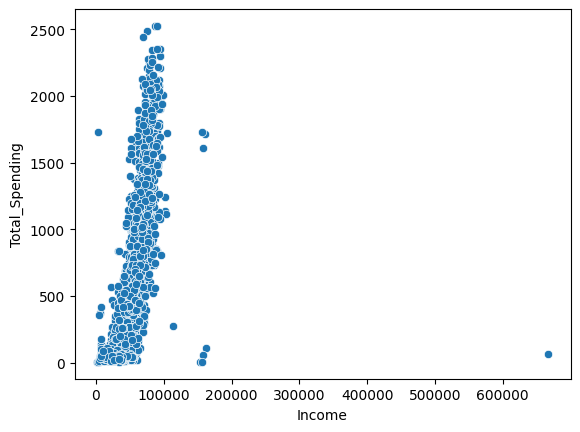

In [18]:
import seaborn as sns
sns.scatterplot(x='Income', y='Total_Spending', data=df)

<Axes: xlabel='Age', ylabel='Total_Spending'>

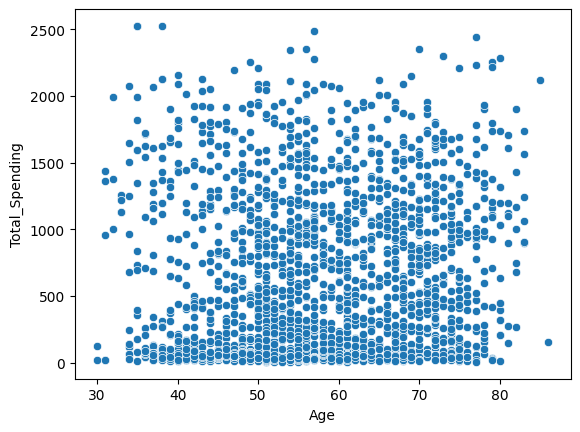

In [22]:
sns.scatterplot(x='Age', y='Total_Spending', data=df)

<Axes: xlabel='Recency', ylabel='Total_Spending'>

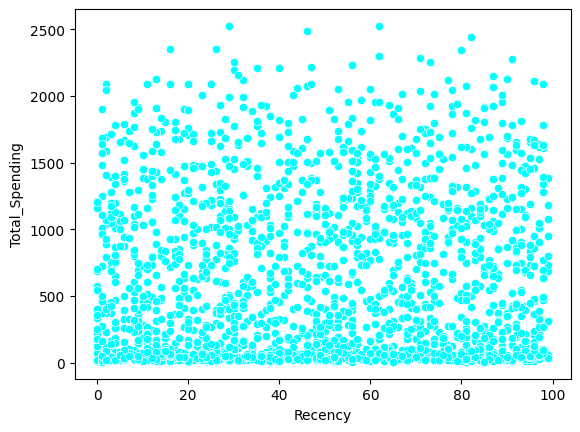

In [19]:
sns.scatterplot(x='Recency', y='Total_Spending', data=df, color = 'cyan')

In [20]:
df = df[df['Income'] < 300000]

In [21]:
df.drop([
    'AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5','Response','Kidhome','Teenhome'], axis=1, inplace=True)

In [22]:
df.head(10)

,ID,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,...,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Total_Spending,Total_Purchases,Total_Children
0,5524,58138.0,58,635,88,546,172,88,88,3,...,False,False,False,True,False,False,False,1617,25,0
1,2174,46344.0,38,11,1,6,2,1,6,2,...,False,False,False,True,False,False,False,27,6,2
2,4141,71613.0,26,426,49,127,111,21,42,1,...,False,False,False,False,True,False,False,776,21,0
3,6182,26646.0,26,11,4,20,10,3,5,2,...,False,False,False,False,True,False,False,53,8,1
4,5324,58293.0,94,173,43,118,46,27,15,5,...,False,False,True,False,False,False,False,422,19,1
5,7446,62513.0,16,520,42,98,0,42,14,2,...,False,False,False,False,True,False,False,716,22,1
6,965,55635.0,34,235,65,164,50,49,27,4,...,False,True,False,False,False,False,False,590,21,1
7,6177,33454.0,32,76,10,56,3,1,23,2,...,False,False,True,False,False,False,False,169,10,1
8,4855,30351.0,19,14,0,24,3,3,2,1,...,False,False,False,False,True,False,False,46,6,1
9,5899,5648.0,68,28,0,6,1,1,13,1,...,False,False,False,False,True,False,False,49,2,2


In [23]:
df.columns

Index(['ID', 'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'Age',
       'Customer_Days', 'Education_2n Cycle', 'Education_Basic',
       'Education_Graduation', 'Education_Master', 'Education_PhD',
       'Marital_Status_Absurd', 'Marital_Status_Alone',
       'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow', 'Marital_Status_YOLO', 'Total_Spending',
       'Total_Purchases', 'Total_Children'],
      dtype='str')

In [24]:
df.drop(['MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'], axis=1, inplace=True)

In [25]:
df.drop(['NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases'], axis=1, inplace=True)

In [26]:
df.drop('NumDealsPurchases', axis = 1, inplace= True)

In [27]:
df.drop(['Education_2n Cycle', 'Education_Basic',
       'Education_Graduation', 'Education_Master', 'Education_PhD',
       'Marital_Status_Absurd', 'Marital_Status_Alone',
       'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow', 'Marital_Status_YOLO'], axis = 1, inplace= True)

In [28]:
df.head()

,ID,Income,Recency,NumWebVisitsMonth,Complain,Age,Customer_Days,Total_Spending,Total_Purchases,Total_Children
0,5524,58138.0,58,7,0,69,4955,1617,25,0
1,2174,46344.0,38,5,0,72,4405,27,6,2
2,4141,71613.0,26,4,0,61,4604,776,21,0
3,6182,26646.0,26,6,0,42,4431,53,8,1
4,5324,58293.0,94,5,0,45,4453,422,19,1


In [44]:
df.to_csv('feature_engineered_dataset.csv', index=False)

In [42]:
df.drop('ID', axis = 1, inplace= True)

In [47]:
df.shape

(2236, 9)

In [48]:
df.columns

Index(['Income', 'Recency', 'NumWebVisitsMonth', 'Complain', 'Age',
       'Customer_Days', 'Total_Spending', 'Total_Purchases', 'Total_Children'],
      dtype='str')

In [49]:
features = [
    'Income',
    'Age',
    'Customer_Days',
    'Recency',
    'Total_Spending',
    'Total_Purchases',
    'Total_Children']

df_clustering = df[features]

In [50]:
df_clustering.head()

,Income,Age,Customer_Days,Recency,Total_Spending,Total_Purchases,Total_Children
0,58138.0,69,4948,58,1617,25,0
1,46344.0,72,4398,38,27,6,2
2,71613.0,61,4597,26,776,21,0
3,26646.0,42,4424,26,53,8,1
4,58293.0,45,4446,94,422,19,1


In [31]:
df_scl = df[[
    "Income",
    "Recency",
    "Customer_Days",
    "Total_Spending",
    "Total_Purchases"]]

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_scl)

In [52]:
print(X_scaled)

[[ 0.2885133   1.01686817  1.52979289 ...  1.6801763   1.31933993
  -1.26430757]
 [-0.26243786  1.27326389 -1.19114282 ... -0.9622024  -1.15585714
   1.39513902]
 [ 0.91799157  0.33314626 -0.20665881 ...  0.28254077  0.79824581
  -1.26430757]
 ...
 [ 0.23446459 -1.03429758 -0.98336227 ...  1.0553119   0.53769875
  -1.26430757]
 [ 0.80737157  1.10233341 -0.97841512 ...  0.39388629  1.05879287
   0.06541573]
 [ 0.04237444  1.27326389  1.3269595  ... -0.72123076 -0.50448949
   1.39513902]]


In [33]:
X_scaled.shape

(2236, 5)

In [34]:
import joblib

joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [54]:
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.to_csv("X_scaled.csv", index=False)